In [2]:
#Mount Colab to Google Drive to save and share files
from google.colab import drive
import os
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MOR-project
!ls

!python3 -m pip install vtk
!python3 -m pip install pypolydim
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
#import sys
#sys.path.insert(0, "/content/drive/MyDrive/MOR-project")
import other_utilities as other_ut



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MOR-project
Export	Meshes	other_utilities.py  __pycache__  Q1.ipynb


In [3]:
#Initalize parameters
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

#All export folders path
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

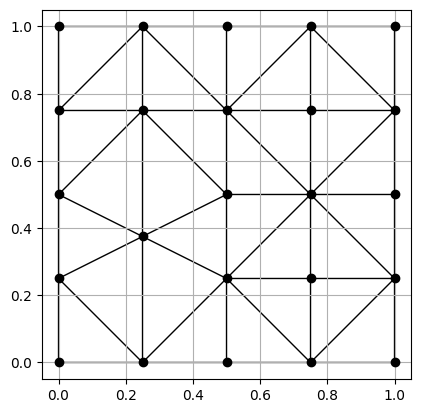

In [4]:
#Define the domain [0,1]x[0,1]
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

#Define the mesh
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular 
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc     
method_order = 1
mesh_size = 0.005

mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

#plot the mesh
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [5]:
print("Vertex markers:", np.unique(mesh_data.cell0_d_markers))
print("Edge markers:", np.unique(mesh_data.cell1_d_markers))

Vertex markers: [0 1 2 3 4 5 6 7 8]
Edge markers: [0 5 6 7 8]


In [6]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet, #fix pressure at (0,0) to 0
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [7]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type, 
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data, 
                                                                                    mesh, 
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info, 
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data, 
                                                                                 mesh, 
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info, 
                                               mesh_connectivity_data)

In [8]:
#amount of DOF's

pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
23 	 1 	 45 	 32 	 113 	 65


In [9]:
#Define the non affine source term

In [10]:
#assemble the FEM matrices
def pressure_strong_function(marker, x, y, z):
    return 0.0

def speed_x_strong_function(marker, x, y, z):
    return 0.0

def speed_y_strong_function(marker, x, y, z):
    return 0.0

p_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_mesh_dofs_info,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_strong_function
)

u_x_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_x_strong_function
)

u_y_strong = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_strong_solution(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_mesh_dofs_info,
    speed_dofs_data,
    speed_reference_element_data,
    speed_y_strong_function
)

strong_solution = np.concatenate([u_x_strong, u_y_strong, p_strong])

In [11]:
#check the dimensions 

print("strong_solution shape:", strong_solution.shape)

print("speed_n_dofs:", speed_n_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("total expected:", 2 * speed_n_dofs + pressure_n_dofs)

strong_solution shape: (65,)
speed_n_dofs: 45
pressure_n_dofs: 23
total expected: 113


In [12]:
def one_term(x, y, z):  
    return 1.0

def b_x_term(x, y, z):  
    return np.array([\
        1.0,\
        0.0,\
        0.0])
def b_y_term(x, y, z):  
    return np.array([\
        0.0,\
        1.0,\
        0.0])


A_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_diffusion_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

A_speed = other_ut.make_np_sparse(A_operator.operator_dofs)

J_A_x = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [0, 0]
)

J_A_y = other_ut.make_np_sparse(
    A_operator.operator_dofs,
    [tot_dofs, tot_dofs],
    [speed_n_dofs, speed_n_dofs]
)

J_A_Base = J_A_x + J_A_y

B_x_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_x_term)
B_y_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_advection_operator(geometry_utilities,
                                                                       mesh,
                                                                       mesh_geometric_data,
                                                                       speed_dofs_data,
                                                                       pressure_dofs_data,
                                                                       speed_reference_element_data,
                                                                       pressure_reference_element_data,
                                                                       b_y_term)

J_B_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0])
J_B_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs])
J_BT_x = other_ut.make_np_sparse(B_x_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, 0], True)
J_BT_y = other_ut.make_np_sparse(B_y_operator.operator_dofs, [tot_dofs, tot_dofs], [2 * speed_n_dofs, speed_n_dofs], True)


J_B = -J_B_x - J_B_y - J_BT_x - J_BT_y

# Velocity mass matrix: int u v dx
M_speed_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    speed_dofs_data,
    speed_dofs_data,
    speed_reference_element_data,
    speed_reference_element_data,
    one_term
)

M_speed = other_ut.make_np_sparse(M_speed_operator.operator_dofs)

# Velocity H1 inner product:
# ||u||^2 + ||grad u||^2 for both u_x and u_y
X_u = scipy.sparse.block_diag(
    [A_speed + M_speed, A_speed + M_speed],
    format="csr"
)

# Pressure mass matrix: int p q dx
M_p_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_reaction_operator(
    geometry_utilities,
    mesh,
    mesh_geometric_data,
    pressure_dofs_data,
    pressure_dofs_data,
    pressure_reference_element_data,
    pressure_reference_element_data,
    one_term
)

M_p = other_ut.make_np_sparse(M_p_operator.operator_dofs)

# Pressure L2 inner product
X_p = M_p

print("A_speed shape:", A_speed.shape)
print("M_speed shape:", M_speed.shape)
print("X_u shape:", X_u.shape)
print("X_p shape:", X_p.shape)

A_speed shape: (45, 45)
M_speed shape: (45, 45)
X_u shape: (90, 90)
X_p shape: (23, 23)


In [13]:
def assemble_source(mu1):
    def f_1_function(x, y, z):
        return -(
            mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * x)
            - mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * y) * np.cos(mu1 * np.pi * y) \
        + mu1 * np.pi * np.cos(mu1 * np.pi * x) * np.cos(mu1 * np.pi * y)

    def f_2_function(x, y, z):
        return -(
            -mu1**3 * np.pi**2 * np.cos(mu1**2 * np.pi * y)
            + mu1**2 * np.pi**2
        ) * np.sin(mu1 * np.pi * x) * np.cos(mu1 * np.pi * x) \
        - mu1 * np.pi * np.sin(mu1 * np.pi * x) * np.sin(mu1 * np.pi * y)

    f_1 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_1_function
    )

    f_2 = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_source_term(
        geometry_utilities,
        mesh,
        mesh_geometric_data,
        speed_dofs_data,
        speed_reference_element_data,
        speed_reference_element_data,
        f_2_function
    )

    f_S = np.concatenate([
        f_1,
        f_2,
        np.zeros(pressure_n_dofs)
    ])

    return f_S

def assemble_stokes_matrix(mu0):
    J_S = mu0 * J_A_Base + J_B
    return J_S


In [14]:
#use same seed for now
np.random.seed(1)
snapshot_num = 100  # number of FOM snapshots

mu0_range = [0.1, 10.0]
mu1_range = [1.0, 3.0]

P = np.array([mu0_range, mu1_range])

training_set = np.random.uniform(
    low=P[:, 0],
    high=P[:, 1],
    size=(snapshot_num, P.shape[0])
)

print(training_set.shape)
print(training_set)



(100, 2)
[[4.22851785 2.44064899]
 [0.10113231 1.60466515]
 [1.55288332 1.18467719]
 [1.94397609 1.69112145]
 [4.02799799 2.07763347]
 [4.25002569 2.370439  ]
 [2.12407727 2.75623487]
 [0.37113717 2.34093502]
 [4.23131754 2.11737966]
 [1.48983069 1.39620298]
 [8.02737123 2.93652315]
 [3.20289936 2.38464523]
 [8.77625261 2.78921333]
 [0.94193769 1.07810957]
 [1.78132115 2.75628501]
 [1.07363365 1.84221525]
 [9.58310635 2.06633057]
 [6.94958343 1.63103126]
 [6.89635918 2.66925134]
 [0.28105395 2.50028863]
 [9.88972478 2.49633131]
 [2.87639552 2.57855866]
 [1.12193747 1.89578705]
 [9.09509548 1.5872283 ]
 [2.94897585 1.26005714]
 [0.29173288 2.35767107]
 [2.19511835 1.53109332]
 [4.96657428 1.10672509]
 [5.78376429 1.29345715]
 [5.93412482 2.39951672]
 [1.11311085 1.82811198]
 [6.97456156 1.82835854]
 [0.59453924 2.07179281]
 [6.67156699 2.02977822]
 [9.45148808 2.17311008]
 [9.04367896 1.27494941]
 [1.47883584 2.61478258]
 [4.03700069 1.33070839]
 [9.28233495 1.69553172]
 [7.53303982 2.4

In [15]:

def solve_fom(mu0, mu1):
    residual_norm = 1.0
    solution_norm = 1.0
    newton_tol = 1.0e-5
    max_iterations = 10
    num_iteration = 1


    # starting guess on initial condition

    def speed_x_initial_condition(x, y, z):  
        return 0.0

    def speed_y_initial_condition(x, y, z):  
        return 0.0

    def pressure_initial_condition(x, y, z):  
        return 0.0

    u_x_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_x_initial_condition).function_dofs
    u_y_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    speed_dofs_data,
                                                                                    speed_reference_element_data,
                                                                                    speed_y_initial_condition).function_dofs
    p_numeric = polydim.pde_tools.assembler_utilities.pcc_2_d.evaluate_function_on_dofs(geometry_utilities,
                                                                                    mesh,
                                                                                    mesh_geometric_data,
                                                                                    pressure_dofs_data,
                                                                                    pressure_reference_element_data,
                                                                                    pressure_initial_condition).function_dofs

    u_k = np.concatenate([u_x_numeric, u_y_numeric, p_numeric])
    du_x_strong = np.zeros(speed_n_strongs)
    du_y_strong = np.zeros(speed_n_strongs)
    dp_strong = np.zeros(pressure_n_strongs)


    #assemble and update source term with mu1
    f_S = assemble_source(mu1)

    #Update J_S with mu0
    J_S = assemble_stokes_matrix(mu0)
    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_y_numeric,
            u_x_strong,
            u_y_strong
        )

        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs,
            [tot_dofs, tot_dofs],
            [0, 0]
        )

        f_C = np.concatenate([
            c_operator.convective_rhs,
            np.zeros(pressure_n_dofs)
        ])

        J_f = f_S - f_C - J_S @ u_k

        du = scipy.sparse.linalg.spsolve(J_S + J_C, J_f)

        u_k = u_k + du

        du_x = du[0:speed_n_dofs]
        du_y = du[speed_n_dofs:2 * speed_n_dofs]
        dp = du[2 * speed_n_dofs:]

        u_x_numeric = u_k[0:speed_n_dofs]
        u_y_numeric = u_k[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_k[2 * speed_n_dofs:]

        du_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_x,
            du_x_strong
        )

        du_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            du_y,
            du_y_strong
        )

        dp_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            dp,
            dp_strong
        )

        u_x_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_x_strong
        )

        u_y_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_y_numeric,
            u_y_strong
        )

        p_norm_L2 = polydim.pde_tools.assembler_utilities.pcc_2_d.compute_error_l2(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            pressure_dofs_data,
            pressure_reference_element_data,
            p_numeric,
            p_strong
        )

        solution_norm = np.sqrt(
            u_x_norm_L2.numeric_norm_l2**2 +
            u_y_norm_L2.numeric_norm_l2**2 +
            p_norm_L2.numeric_norm_l2**2
        )

        residual_norm = np.sqrt(
            du_x_norm_L2.numeric_norm_l2**2 +
            du_y_norm_L2.numeric_norm_l2**2 +
            dp_norm_L2.numeric_norm_l2**2
        )
                
        num_iteration = num_iteration + 1


    info = {
        "mu0": mu0,
        "mu1": mu1,
        "iterations": num_iteration - 1,
        "final_ratio": residual_norm / solution_norm,
        "converged": residual_norm <= newton_tol * solution_norm
    }

    return u_k, u_x_numeric, u_y_numeric, p_numeric, info
    

In [16]:
snapshot_matrix = []
info_list = []

for i, mu in enumerate(training_set):
    mu0 = mu[0]
    mu1 = mu[1]

    print(f"Snapshot {i+1}/{snapshot_num}: mu0={mu0:.4f}, mu1={mu1:.4f}")

    u_k, u_x_numeric, u_y_numeric, p_numeric, info = solve_fom(mu0, mu1)

    snapshot_matrix.append(np.copy(u_k))
    info_list.append(info)

snapshot_matrix = np.array(snapshot_matrix)

S_u = snapshot_matrix[:, :2 * speed_n_dofs]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]

print("S_u shape:", S_u.shape)
print("S_p shape:", S_p.shape)


Snapshot 1/100: mu0=4.2285, mu1=2.4406
Snapshot 2/100: mu0=0.1011, mu1=1.6047
Snapshot 3/100: mu0=1.5529, mu1=1.1847
Snapshot 4/100: mu0=1.9440, mu1=1.6911
Snapshot 5/100: mu0=4.0280, mu1=2.0776
Snapshot 6/100: mu0=4.2500, mu1=2.3704
Snapshot 7/100: mu0=2.1241, mu1=2.7562
Snapshot 8/100: mu0=0.3711, mu1=2.3409
Snapshot 9/100: mu0=4.2313, mu1=2.1174
Snapshot 10/100: mu0=1.4898, mu1=1.3962
Snapshot 11/100: mu0=8.0274, mu1=2.9365
Snapshot 12/100: mu0=3.2029, mu1=2.3846
Snapshot 13/100: mu0=8.7763, mu1=2.7892
Snapshot 14/100: mu0=0.9419, mu1=1.0781
Snapshot 15/100: mu0=1.7813, mu1=2.7563
Snapshot 16/100: mu0=1.0736, mu1=1.8422
Snapshot 17/100: mu0=9.5831, mu1=2.0663
Snapshot 18/100: mu0=6.9496, mu1=1.6310
Snapshot 19/100: mu0=6.8964, mu1=2.6693
Snapshot 20/100: mu0=0.2811, mu1=2.5003
Snapshot 21/100: mu0=9.8897, mu1=2.4963
Snapshot 22/100: mu0=2.8764, mu1=2.5786
Snapshot 23/100: mu0=1.1219, mu1=1.8958
Snapshot 24/100: mu0=9.0951, mu1=1.5872
Snapshot 25/100: mu0=2.9490, mu1=1.2601
Snapshot 

In [17]:
# Pressure-to-velocity coupling block
BT = J_B[:2 * speed_n_dofs, 2 * speed_n_dofs:]

print("BT shape:", BT.shape)
print("X_u shape:", X_u.shape)

snapshot_matrix_s = []

for i in range(S_p.shape[0]):
    snapshot_p = S_p[i, :]

    rhs_s = BT @ snapshot_p

    snapshot_s = scipy.sparse.linalg.spsolve(X_u, rhs_s)

    snapshot_matrix_s.append(np.copy(snapshot_s))

snapshot_matrix_s = np.array(snapshot_matrix_s)

print("snapshot_matrix_s shape:", snapshot_matrix_s.shape)

BT shape: (90, 23)
X_u shape: (90, 90)
snapshot_matrix_s shape: (100, 90)


In [18]:
print("snapshot_matrix shape:", snapshot_matrix.shape)
#check snapshot matrix same shape as total dofs x num. training
print("total DOF's:", tot_dofs)
print("pressure_n_dofs:", pressure_n_dofs)
print("pressure_n_strongs:", pressure_n_strongs)
print("speed_n_dofs:", speed_n_dofs)
print("speed_n_strongs:", speed_n_strongs)


snapshot_matrix shape: (100, 113)
total DOF's: 113
pressure_n_dofs: 23
pressure_n_strongs: 1
speed_n_dofs: 45
speed_n_strongs: 32


In [19]:
def build_pod_basis_from_snapshots(S, inner_product):
    C = S @ inner_product @ S.T
    tol=1.0 - 1e-7
    eigenvalues, eigenvectors = np.linalg.eigh(C)

    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    eigenvalues = np.maximum(eigenvalues, 0.0)

    total_energy = np.sum(eigenvalues)
    relative_retained_energy = np.cumsum(eigenvalues) / total_energy

    N = np.argmax(relative_retained_energy >= tol) + 1

    basis_functions = []

    for n in range(N):
        eigenvector = eigenvectors[:, n]

        basis = S.T @ eigenvector

        norm = np.sqrt(basis.T @ inner_product @ basis)

        if norm < 1e-14:
            print(f"Skipping mode {n}: norm too small")
            continue

        basis /= norm
        basis_functions.append(np.copy(basis))

    basis_functions = np.array(basis_functions).T

    return basis_functions, eigenvalues, relative_retained_energy, N

In [20]:
V_u, eig_u, energy_u, N_u = build_pod_basis_from_snapshots(S_u, X_u)

V_p, eig_p, energy_p, N_p = build_pod_basis_from_snapshots(S_p, X_p)

V_s, eig_s, energy_s, N_s = build_pod_basis_from_snapshots(snapshot_matrix_s, X_u)

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("N_u:", N_u)
print("N_p:", N_p)

G_u = V_u.T @ X_u @ V_u
G_p = V_p.T @ X_p @ V_p

print("V_u shape:", V_u.shape)
print("V_p shape:", V_p.shape)
print("V_s shape:", V_s.shape)

print("N_u:", N_u)
print("N_p:", N_p)
print("N_s:", N_s)

print("Velocity orthonormality error:",
      np.linalg.norm(V_u.T @ X_u @ V_u - np.eye(V_u.shape[1])))

print("Pressure orthonormality error:",
      np.linalg.norm(V_p.T @ X_p @ V_p - np.eye(V_p.shape[1])))

print("Supremizer orthonormality error:",
      np.linalg.norm(V_s.T @ X_u @ V_s - np.eye(V_s.shape[1])))


V_u shape: (90, 22)
V_p shape: (23, 21)
N_u: 22
N_p: 21
V_u shape: (90, 22)
V_p shape: (23, 21)
V_s shape: (90, 22)
N_u: 22
N_p: 21
N_s: 22
Velocity orthonormality error: 2.1742520762980407e-10
Pressure orthonormality error: 2.94153190049092e-11
Supremizer orthonormality error: 7.287918228850879e-12


In [21]:
# Enrich velocity basis with supremizer basis
V_u_enriched = np.column_stack([V_u, V_s])

V_u_enriched, _ = np.linalg.qr(V_u_enriched)

V_rom = scipy.linalg.block_diag(V_u_enriched, V_p)

print("V_rom shape:", V_rom.shape)

V_rom shape: (113, 65)


In [22]:
# Velocity snapshots: [u_x, u_y]
S_u = snapshot_matrix[:, :2 * speed_n_dofs]

# Pressure snapshots: [p]
S_p = snapshot_matrix[:, 2 * speed_n_dofs:]


# Check one snapshot
j = 0

snapshot_u_j = S_u[j, :]
snapshot_p_j = S_p[j, :]

# Project onto POD spaces
coeff_u_j = V_u.T @ X_u @ snapshot_u_j
coeff_p_j = V_p.T @ X_p @ snapshot_p_j

# Reconstruct
reconstruction_u_j = V_u @ coeff_u_j
reconstruction_p_j = V_p @ coeff_p_j

# Relative errors using Euclidean norm for easy interpretation
relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

print("Velocity reconstruction error for snapshot 0:", relative_error_u)
print("Pressure reconstruction error for snapshot 0:", relative_error_p)


# Check all snapshots
velocity_errors = []
pressure_errors = []

for j in range(snapshot_matrix.shape[0]):
    snapshot_u_j = S_u[j, :]
    snapshot_p_j = S_p[j, :]

    coeff_u_j = V_u.T @ X_u @ snapshot_u_j
    coeff_p_j = V_p.T @ X_p @ snapshot_p_j

    reconstruction_u_j = V_u @ coeff_u_j
    reconstruction_p_j = V_p @ coeff_p_j

    relative_error_u = np.linalg.norm(snapshot_u_j - reconstruction_u_j) / np.linalg.norm(snapshot_u_j)
    relative_error_p = np.linalg.norm(snapshot_p_j - reconstruction_p_j) / np.linalg.norm(snapshot_p_j)

    velocity_errors.append(relative_error_u)
    pressure_errors.append(relative_error_p)

velocity_errors = np.array(velocity_errors)
pressure_errors = np.array(pressure_errors)

print("Velocity max reconstruction error:", np.max(velocity_errors))
print("Velocity mean reconstruction error:", np.mean(velocity_errors))
print("Velocity min reconstruction error:", np.min(velocity_errors))

print("Pressure max reconstruction error:", np.max(pressure_errors))
print("Pressure mean reconstruction error:", np.mean(pressure_errors))
print("Pressure min reconstruction error:", np.min(pressure_errors))

Velocity reconstruction error for snapshot 0: 0.0010486101454515553
Pressure reconstruction error for snapshot 0: 9.290441381466047e-05
Velocity max reconstruction error: 0.0025149086317468776
Velocity mean reconstruction error: 0.0010108243112241257
Velocity min reconstruction error: 2.937894155993682e-07
Pressure max reconstruction error: 0.0025817376943425897
Pressure mean reconstruction error: 0.0003670063796290931
Pressure min reconstruction error: 2.395033538820041e-05


In [23]:
#build the reduced assembly matrices
V_u_enriched = np.column_stack([V_u, V_s])

V_u_enriched, _ = np.linalg.qr(V_u_enriched)

V_rom = scipy.linalg.block_diag(V_u_enriched, V_p)

J_A_r = V_rom.T @ J_A_Base @ V_rom
J_B_r = V_rom.T @ J_B @ V_rom

def assemble_reduced_stokes_matrix(mu0):
    return mu0 * J_A_r + J_B_r

#newton solver for the reduced order model
def solve_rom(mu0, mu1):
    # Assemble full source vector and project it.
    # This is needed source term is non-affine.
    f_S = assemble_source(mu1)
    f_S_r = V_rom.T @ f_S

    
    J_S_r = assemble_reduced_stokes_matrix(mu0)

    # Initial reduced coefficient vector
    N_rom = V_rom.shape[1]
    a_k = np.zeros(N_rom)

    #iteration settings
    max_iterations = 50
    newton_tol=1e-6
    residual_norm = 1.0
    solution_norm = 1.0
    num_iteration = 1

    while num_iteration < max_iterations and residual_norm > newton_tol * solution_norm:

        # Reconstruct full solution from reduced coefficients
        u_full = V_rom @ a_k

        # Split full reconstructed solution
        u_x_numeric = u_full[0:speed_n_dofs]
        u_y_numeric = u_full[speed_n_dofs:2 * speed_n_dofs]
        p_numeric = u_full[2 * speed_n_dofs:]


        # Assemble nonlinear convection operator using reconstructed full velocity
        c_operator = polydim.pde_tools.assembler_utilities.pcc_2_d.assemble_ns_operators(
            geometry_utilities,
            mesh,
            mesh_geometric_data,
            speed_dofs_data,
            speed_reference_element_data,
            u_x_numeric,
            u_y_numeric,
            u_x_strong,
            u_y_strong
        )

        # Full convective Jacobian contribution
        J_C = other_ut.make_np_sparse(
            c_operator.convective_operator.operator_dofs,
            [tot_dofs, tot_dofs],
            [0, 0]
        )

        # Full nonlinear RHS contribution
        f_C = np.concatenate([
            c_operator.convective_rhs,
            np.zeros(pressure_n_dofs)
        ])

        # Project nonlinear terms to reduced space
        J_C_r = V_rom.T @ J_C @ V_rom
        f_C_r = V_rom.T @ f_C

        # Reduced Newton RHS
        J_f_r = f_S_r - f_C_r - J_S_r @ a_k

        # Reduced Newton matrix
        J_r = J_S_r + J_C_r

        # Solve reduced Newton correction
        da = np.linalg.solve(J_r, J_f_r)

        # Update reduced coefficients
        a_k = a_k + da

        # Convergence check
        residual_norm = np.linalg.norm(da)
        solution_norm = np.linalg.norm(a_k)



        num_iteration += 1

    # Final reconstructed ROM solution
    u_rom = V_rom @ a_k

    u_x_rom = u_rom[0:speed_n_dofs]
    u_y_rom = u_rom[speed_n_dofs:2 * speed_n_dofs]
    p_rom = u_rom[2 * speed_n_dofs:]

    info = {
        "mu0": mu0,
        "mu1": mu1,
        "iterations": num_iteration - 1,
        "final_ratio": residual_norm / solution_norm,
        "converged": residual_norm <= newton_tol * solution_norm
    }

    return u_rom, u_x_rom, u_y_rom, p_rom, info



In [24]:
mu0_values = [0.1, 1.0, 2.5, 5.0, 7.5, 10.0]

for mu0 in mu0_values:
    J_S_r_test = assemble_reduced_stokes_matrix(mu0)

    print(f"\nmu0 = {mu0}")
    print("J_S_r shape:", J_S_r_test.shape)
    print("rank:", np.linalg.matrix_rank(J_S_r_test))
    print("condition number:", np.linalg.cond(J_S_r_test))


mu0 = 0.1
J_S_r shape: (65, 65)
rank: 65
condition number: 274.1368157933547

mu0 = 1.0
J_S_r shape: (65, 65)
rank: 65
condition number: 11034.958895055717

mu0 = 2.5
J_S_r shape: (65, 65)
rank: 65
condition number: 68871.92149584989

mu0 = 5.0
J_S_r shape: (65, 65)
rank: 65
condition number: 275434.9583506796

mu0 = 7.5
J_S_r shape: (65, 65)
rank: 65
condition number: 619706.830439895

mu0 = 10.0
J_S_r shape: (65, 65)
rank: 65
condition number: 1101687.470119775


In [25]:
mu0_test = 10.0
mu1_test = 2.0

u_rom, u_x_rom, u_y_rom, p_rom, a_rom, info_rom = solve_rom(mu0_test, mu1_test)
u_fom, u_x_fom, u_y_fom, p_fom, info_fom = solve_fom(mu0_test, mu1_test)

rel_error = np.linalg.norm(u_fom - u_rom) / np.linalg.norm(u_fom)

total_error = np.linalg.norm(u_fom - u_rom) / np.linalg.norm(u_fom)

du = u_fom[:2*speed_n_dofs] - u_rom[:2*speed_n_dofs]
u_ref = u_fom[:2*speed_n_dofs]

velocity_error = np.sqrt(du.T @ X_u @ du) / np.sqrt(u_ref.T @ X_u @ u_ref)

dp = u_fom[2*speed_n_dofs:] - u_rom[2*speed_n_dofs:]
p_ref = u_fom[2*speed_n_dofs:]

pressure_error = np.sqrt(dp.T @ X_p @ dp) / np.sqrt(p_ref.T @ X_p @ p_ref)

print("Total ROM/FOM relative error:", total_error)
print("Velocity ROM/FOM relative error:", velocity_error)
print("Pressure ROM/FOM relative error:", pressure_error)
print("FOM info:", info_fom)
print("ROM info:", info_rom)

ValueError: not enough values to unpack (expected 6, got 5)

In [ ]:
import time
import pandas as pd

mu0_values = np.linspace(0.1, 10.0, 5)
mu1_values = np.linspace(1.0, 3.0, 5)

results = []
n_u = V_u.shape[0]
for mu0 in mu0_values:
    for mu1 in mu1_values:
        print(f"Testing mu0={mu0:.2f}, mu1={mu1:.2f}")

        start = time.perf_counter()
        u_fom_full, ux_fom, uy_fom, p_fom, fom_info = solve_fom(mu0, mu1)
        fom_time = time.perf_counter() - start

        start = time.perf_counter()
        u_rom_full, ux_rom, uy_rom, p_rom, rom_info = solve_rom(mu0, mu1)
        rom_time = time.perf_counter() - start

        velocity_error = np.linalg.norm(u_fom_full - u_rom_full) / np.linalg.norm(u_fom_full)

        pressure_error = np.linalg.norm(p_fom - p_rom) / np.linalg.norm(p_fom)

        U_fom = np.concatenate([u_fom_full, p_fom])
        U_rom = np.concatenate([u_rom_full, p_rom])

        total_error = np.linalg.norm(U_fom - U_rom) / np.linalg.norm(U_fom)

        speedup = fom_time / rom_time

        results.append({
            "mu0": mu0,
            "mu1": mu1,
            "velocity_error": velocity_error,
            "pressure_error": pressure_error,
            "total_error": total_error,
            "fom_time": fom_time,
            "rom_time": rom_time,
            "speedup": speedup,
            "fom_iterations": fom_info["iterations"],
            "rom_iterations": rom_info["iterations"]
        })

df_results = pd.DataFrame(results)
df_results

Testing mu0=0.10, mu1=1.00
Testing mu0=0.10, mu1=1.50
Testing mu0=0.10, mu1=2.00
Testing mu0=0.10, mu1=2.50
Testing mu0=0.10, mu1=3.00
Testing mu0=2.58, mu1=1.00
Testing mu0=2.58, mu1=1.50
Testing mu0=2.58, mu1=2.00
Testing mu0=2.58, mu1=2.50
Testing mu0=2.58, mu1=3.00
Testing mu0=5.05, mu1=1.00
Testing mu0=5.05, mu1=1.50
Testing mu0=5.05, mu1=2.00
Testing mu0=5.05, mu1=2.50
Testing mu0=5.05, mu1=3.00
Testing mu0=7.53, mu1=1.00
Testing mu0=7.53, mu1=1.50
Testing mu0=7.53, mu1=2.00
Testing mu0=7.53, mu1=2.50
Testing mu0=7.53, mu1=3.00
Testing mu0=10.00, mu1=1.00
Testing mu0=10.00, mu1=1.50
Testing mu0=10.00, mu1=2.00
Testing mu0=10.00, mu1=2.50
Testing mu0=10.00, mu1=3.00


,mu0,mu1,velocity_error,pressure_error,total_error,fom_time,rom_time,speedup,fom_iterations,rom_iterations
0,0.100,1.0,0.016877,0.019484,0.017534,1.705475,1.284375,1.327864,4,4
1,0.100,1.5,0.034488,0.054980,0.040845,1.899785,0.943508,2.013532,4,5
2,0.100,2.0,0.036236,0.041865,0.037932,1.238159,0.756087,1.637588,4,4
3,0.100,2.5,0.020074,0.023963,0.021644,1.278906,0.733342,1.743941,4,4
4,0.100,3.0,0.089269,0.097407,0.092724,1.218960,0.746600,1.632681,4,4
5,2.575,1.0,0.003803,0.003809,0.003806,1.013751,0.561044,1.806901,3,3
6,2.575,1.5,0.000299,0.000292,0.000296,0.982412,0.834695,1.176970,3,3
7,2.575,2.0,0.000729,0.000741,0.000735,1.628906,1.084826,1.501536,3,3
8,2.575,2.5,0.000118,0.000118,0.000118,1.455172,0.564702,2.576884,3,3
9,2.575,3.0,0.000868,0.000866,0.000867,0.976848,0.559455,1.746070,3,3


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Choose what you want to plot on z-axis
#input = "speedup"
# input = "pressure_error"
input = "total_error"
# input = "speedup"

# Create sorted parameter arrays
mu0_values = np.sort(df_results["mu0"].unique())
mu1_values = np.sort(df_results["mu1"].unique())

# Create meshgrid
MU0, MU1 = np.meshgrid(mu0_values, mu1_values, indexing="ij")

# Convert dataframe values to 2D grid
Z = df_results.pivot(
    index="mu0",
    columns="mu1",
    values=input
).values

# Plot
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    MU0,
    MU1,
    Z,
    cmap="viridis",      # blue/green/yellow map like your example
    edgecolor="k",       # black grid lines
    linewidth=0.4,
    antialiased=True,
    alpha=0.95
)

ax.set_xlabel(r"$\mu_0$")
ax.set_ylabel(r"$\mu_1$")
ax.set_zlabel(input)

ax.set_title(f"3D surface plot of {input}")

# Camera angle similar to your example
ax.view_init(elev=25, azim=-125)

# Optional: make plot proportions nicer
ax.set_box_aspect((1.4, 1.0, 0.6))

# Add colorbar
fig.colorbar(surface, ax=ax, shrink=0.6, aspect=12, label=input)

plt.show()

NameError: name 'df_results' is not defined